# Lab 9: Implement K-Means, Agglomerative Hierarchical, and DBSCAN in Python

## Objective
Understand and implement K-Means, Agglomerative Hierarchical Clustering, and DBSCAN with Python, then visualize the results.

## Theory
Clustering is an unsupervised method for grouping similar data points. K-Means partitions data into K clusters by minimizing intra-cluster variance. Agglomerative Hierarchical Clustering builds a cluster tree by successively merging the closest points or clusters. DBSCAN identifies dense regions of points as clusters and marks points in sparse regions as noise.

K-Means centroids: [[1.5        1.2       ]
 [7.06666667 1.56666667]
 [5.63636364 6.73636364]]
Cluster 0: 3 points
Cluster 1: 6 points
Cluster 2: 11 points


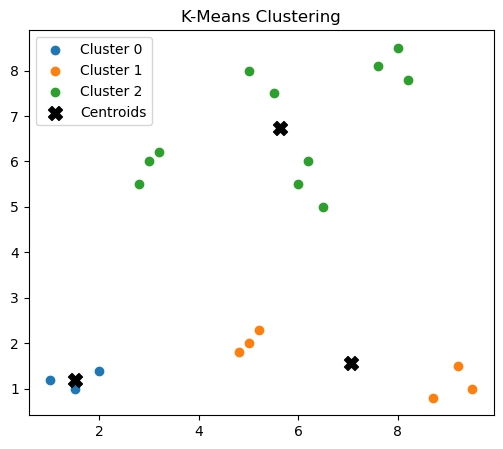

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import math

base_dir = r"d:/Aayush_Acharya/7th Sem/DWDM/Lab 9"
df = pd.read_csv(f"{base_dir}/sample_points.csv")
points = df[['x', 'y']].values

# K-Means implementation
def kmeans(points, k, max_iters=100):
    centroids = points[:k].copy()
    for _ in range(max_iters):
        clusters = [[] for _ in range(k)]
        for p in points:
            distances = [np.linalg.norm(p - c) for c in centroids]
            clusters[np.argmin(distances)].append(p)
        new_centroids = []
        for cluster in clusters:
            if cluster:
                new_centroids.append(np.mean(cluster, axis=0))
            else:
                new_centroids.append(centroids[len(new_centroids)])
        new_centroids = np.array(new_centroids)
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, clusters

centroids, clusters = kmeans(points, k=3)
print('K-Means centroids:', centroids)
for i, cluster in enumerate(clusters):
    print(f'Cluster {i}:', len(cluster), 'points')

plt.figure(figsize=(6, 5))
for i, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    if len(cluster) > 0:
        plt.scatter(cluster[:,0], cluster[:,1], label=f'Cluster {i}')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=100, label='Centroids')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

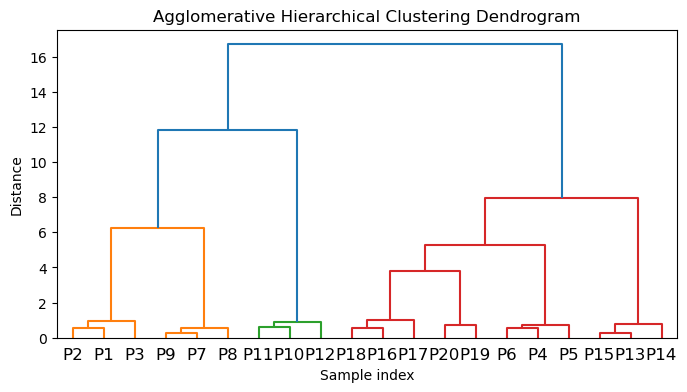

In [2]:
# Agglomerative Hierarchical Clustering using SciPy
Z = linkage(points, method='ward')

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=[f'P{i+1}' for i in range(len(points))], orientation='top', distance_sort='descending')
plt.title('Agglomerative Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

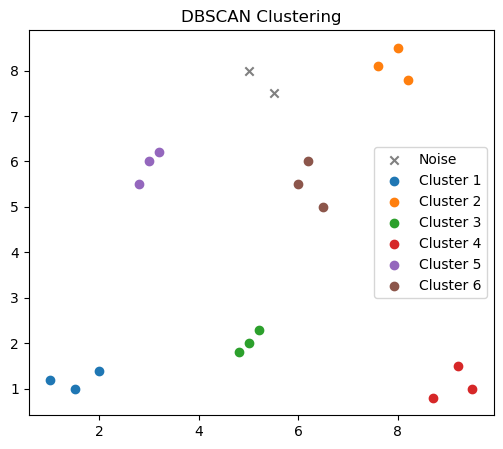

In [3]:
# Simple manual DBSCAN implementation

def dbscan(points, eps=1.5, min_pts=3):
    labels = [0] * len(points)
    cluster_id = 0
    def region_query(i):
        return [j for j, p in enumerate(points) if np.linalg.norm(points[i]-p) <= eps]

    for i in range(len(points)):
        if labels[i] != 0:
            continue
        neighbors = region_query(i)
        if len(neighbors) < min_pts:
            labels[i] = -1
            continue
        cluster_id += 1
        labels[i] = cluster_id
        seeds = [n for n in neighbors if n != i]
        while seeds:
            current = seeds.pop()
            if labels[current] == -1:
                labels[current] = cluster_id
            if labels[current] != 0:
                continue
            labels[current] = cluster_id
            current_neighbors = region_query(current)
            if len(current_neighbors) >= min_pts:
                seeds.extend([n for n in current_neighbors if labels[n] == 0])
    return labels

labels = dbscan(points, eps=1.5, min_pts=3)
unique_labels = sorted(set(labels))

plt.figure(figsize=(6, 5))
for label in unique_labels:
    cluster_points = points[[i for i, l in enumerate(labels) if l == label]]
    if label == -1:
        plt.scatter(cluster_points[:,0], cluster_points[:,1], c='gray', marker='x', label='Noise')
    else:
        plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {label}')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()

## Discussion
The notebook demonstrates three clustering methods on a generic 2D point dataset. K-Means partitions the data into fixed clusters by iteratively updating centroids. Agglomerative clustering builds a dendrogram showing how data points merge into clusters. DBSCAN detects dense regions and identifies any points that do not belong to a cluster as noise.

## Conclusion
This lab illustrates how different clustering methods behave on the same dataset. K-Means works well for compact clusters when K is known. Agglomerative clustering provides a hierarchical structure without requiring a preset number of clusters. DBSCAN detects clusters of varying shape and separates noise automatically.